In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('/home/admin/Documents/0_hw/src')

# Import modules

In [3]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from IPython.display import display

import seaborn as sns
import xgboost as xgb
import yaml
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import KFold

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
import xgboost as xgb
from tqdm import tqdm
import re
import pickle
from sklearn.metrics import roc_curve, auc
import re

from tqdm import trange
import pickle
import os
import optuna

from optuna.storages import JournalStorage
from optuna.storages.journal import JournalFileBackend
import threading
import gc

from sklearn.manifold import TSNE
import umap
import dill

/home/admin/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/admin/.local/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [4]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [5]:
from utils import PROCESS_STEPS, INPUT_PROFILE, DATA_TYPES
from utils import ColumnClassifier
from utils import squeeze_list

# Load data

In [6]:
data_path = '/home/admin/Documents/0_hw/notebooks/model/260706_feature_store_v3_1_after_cut.parquet'
data = pd.read_parquet(data_path)

In [7]:
data

,07_Before Degas_Cell ID,BASE_ID,01_Mixing_Lot ID,01_Mixing_Equipment ID,01_Mixing_Finished Date,02_Coating(Back)_Lot ID,02_Coating(Back)_Equipment ID,02_Coating(Back)_Finished Date,03_Roll Pressing_Lot ID,03_Roll Pressing_Equipment ID,...,DV86__음극 3단 시작 장력 * 가속도 WINDING 1,DV86__음극 3단 완료 장력 * 가속도 WINDING 1,DV86__음극 권취 감속위치 장력 * 가속도 WINDING 1,DV86__음극 커팅 장력 * 가속도 WINDING 1,DV86__음극 커팅 후 투입 장력 * 가속도 WINDING 1,DV86__양극 Buffer 자동 장력 * 가속도 WINDING 1,DV86__양극 Buffer 수동 장력 * 가속도 WINDING 1,DV86__음극 Buffer 자동 장력 * 가속도 WINDING 1,DV86__음극 Buffer 수동 장력 * 가속도 WINDING 1,DV86__양극 스풀 장력 * 가속도 WINDING 1
0,07TCED7LGC0021G2F2012903,"[59JFB152A1, 59JFB152A1, 59JFB152A1]","[5A2F201001, 5C2F212004, 5C3F212003]","[M2EMIX01602, M2EMIX01203, M2EMIX01303]",2026-02-02 01:28:10,"[5AF2B116C1, 5CF2D132C1, 5CF2D132C1]","[M2ECOT002, M2ECOT001, M2ECOT001]","[2026-02-11 08:25:07, 2026-02-13 14:19:19, 202...","[5AF2B116R1, 5CF2D132R1, 5CF2D132R1]","[M2EROL011, M2EROL012, M2EROL012]",...,280.0,280.0,280.0,260.0,220.0,280.0,280.0,250.0,250.0,360.0
1,07TCED7LGC0021G392090493,[59JFC092A1],[],[],NaT,[],[],[],[],[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,07TCED7LGC0021G262047749,"[59JFB062A1, 59JFB062A1]",[5A2F201001],[M2EMIX01602],2026-02-02 01:28:10,"[5AF22149C1, 5CF1R166C1]","[M2ECOT002, M2ECOT001]","[2026-02-02 17:57:06, 2026-01-27 22:35:42]","[5AF22149R1, 5CF1R166R1]","[M2EROL014, M2EROL012]",...,280.0,280.0,280.0,260.0,220.0,280.0,280.0,250.0,250.0,360.0
3,07TCED7LGC0021G3G2115835,"[59JFC162A1, 59JFC162A1, 59JFC162A1]","[5C3F309003, 5A1F303001, 5A2F304003]","[M2EMIX01303, M2EMIX01502, M2EMIX01602]",2026-03-09 12:48:18,"[5CF3B163C1, 5AF37118C1, 5AF37118C1]","[M2ECOT001, M2ECOT002, M2ECOT002]","[2026-03-11 17:22:16, 2026-03-07 08:03:44, 202...","[5CF3B163R1, 5AF37118R1, 5AF37118R1]","[M2EROL015, M2EROL011, M2EROL011]",...,280.0,280.0,280.0,260.0,220.0,280.0,280.0,250.0,250.0,360.0
4,07TCED7LGC0021G102107196,"[59JFA312A1, 59JFA312A1, 59JFA312A1]","[5A2F105002, 5A1F105002, 5C2F112017]","[M2EMIX01602, M2EMIX01502, M2EMIX01203]",2026-01-05 15:32:03,"[5AF1N18AC1, 5AF1N18AC1, 5CF1H125C1]","[M2ECOT002, M2ECOT002, M2ECOT001]","[2026-01-24 02:22:32, 2026-01-24 02:22:32, 202...","[5AF1N18AR1, 5AF1N18AR1, 5CF1H125R1]","[M2EROL011, M2EROL011, M2EROL015]",...,280.0,280.0,280.0,260.0,220.0,280.0,280.0,250.0,250.0,360.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14760,07TCED7LGC0021G3C2046223,"[59JFC122A1, 59JFC122A1, 59JFC122A1]","[5C1F309003, 5A3F303003, 5A4F303001]","[M2EMIX01103, M2EMIX01702, M2EMIX01802]",2026-03-09 14:58:10,"[5CF39161C1, 5AF37179C1, 5AF37179C1]","[M2ECOT001, M2ECOT002, M2ECOT002]","[2026-03-10 05:31:10, 2026-03-07 23:49:56, 202...","[5CF39161R1, 5AF37179R1, 5AF37179R1]","[M2EROL015, M2EROL014, M2EROL014]",...,280.0,280.0,280.0,260.0,220.0,280.0,280.0,250.0,250.0,360.0
14761,07TCED7LGC0021G102008639,"[59JFA312A1, 59JFA312A1, 59JFA312A1]","[5A2F105002, 5A1F105002]","[M2EMIX01602, M2EMIX01502]",2026-01-05 15:32:03,"[5AF1N168C1, 5AF1N168C1, 5CF1R1A2C1]","[M2ECOT002, M2ECOT002, M2ECOT001]","[2026-01-23 21:12:17, 2026-01-23 21:12:17, 202...","[5AF1N168R1, 5AF1N168R1, 5CF1R1A2R1]","[M2EROL011, M2EROL011, M2EROL012]",...,280.0,280.0,280.0,260.0,220.0,280.0,280.0,250.0,250.0,380.0
14762,07TCED7LGC0021G3H2062072,"[59JFC172A1, 59JFC172A1]",[5C2F309006],[M2EMIX01203],2026-03-09 11:11:35,[5CF3B134C1],[M2ECOT001],[2026-03-11 12:02:30],"[5AF1L159R1, 5CF3B134R1]","[M2EROL014, M2EROL013]",...,280.0,280.0,280.0,260.0,220.0,280.0,280.0,250.0,250.0,360.0
14763,07TCED7LGC0021G252085453,"[59JFB052A1, 59JFB052A1]",[5A2F201001],[M2EMIX01602],2026-02-02 01:28:10,"[5AF23122C1, 5CF1S155C1]","[M2ECOT002, M2ECOT001]","[2026-02-03 10:57:11, 2026-01-28 22:59:48]","[5AF23122R1, 5CF1S155R1]","[M2EROL011, M2EROL015]",...,280.0,280.0,280.0,260.0,220.0,280.0,280.0,250.0,250.0,360.0


# Get column list

In [8]:
column_classifier = ColumnClassifier()
df_cols = column_classifier.transform(data=data)

In [9]:
cols_small_y = (
    df_cols.loc[lambda x :x['data_type'] == 'Small_Y', 'cols']
    .tolist()
)
cols_small_y = squeeze_list(cols_small_y)
cols_small_y = [x for x in cols_small_y if x in data.columns]
cols_small_y[:5]

['y_MES_Electrode_Coating_Anode_치수_Loading (Back)',
 'y_LQC_Electrode_Coating_Cathode_Sliding(+)_Tab Back',
 'y_MES_Electrode_Coating_Cathode_절연 (Back)',
 'y_LQC_Electrode_Coating_Anode_Sliding (-)_Tab Back',
 'y_LQC_Electrode_Coating_Cathode_Fat_edge_Tab Back']

In [10]:
cols_sv = (
    df_cols.loc[lambda x :x['data_type'] == 'SV', 'cols']
    .tolist()
)
cols_sv = squeeze_list(cols_sv)
cols_sv[:5]

['X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight',
 'X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight',
 'X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight',
 'X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time',
 'X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight']

In [11]:
cols_pv = (
    df_cols.loc[lambda x :x['data_type'] == 'PV', 'cols']
    .tolist()
)
cols_pv = squeeze_list(cols_pv)
cols_pv[:5]

['X_PV_Electrode_Mixing_Anode_D0012010_N_CO_trev_1_num',
 'X_PV_Electrode_Mixing_Anode_D0012010_N_MD_hrv_classic_pnn40',
 'X_PV_Electrode_Mixing_Anode_D0012010_N_SB_TransitionMatrix_3ac_sumdiagcov',
 'X_PV_Electrode_Mixing_Anode_D0012010_N_PD_PeriodicityWang_th0_01',
 'X_PV_Electrode_Mixing_Anode_D0012010_N_CO_Embed2_Dist_tau_d_expfit_meandiff']

# Preprocess data

In [12]:
# 1. 중복 컬럼 제거
data = data.loc[:, ~data.columns.duplicated()]

In [13]:
# 2. small y 결측값 fill
for col in tqdm(cols_small_y): 
    data.loc[:, col] = data.loc[:, col].fillna(0)
#data.loc[:, list(set(cols_small_y))] = data.loc[:, list(set(cols_small_y))].fillna(0)

100%|██████████| 87/87 [00:00<00:00, 1778.37it/s]


In [14]:
# 3. datetime 처리
data['07_Before Degas_Finished Date'] = pd.to_datetime(data['07_Before Degas_Finished Date'])
data['week'] = data['07_Before Degas_Finished Date'].dt.isocalendar().week
data['date'] = data['07_Before Degas_Finished Date'].dt.date

In [15]:
# 4. PV 결측값 fill
for col in tqdm(cols_pv) : 
    data.loc[:, col] = data.loc[:, col].fillna(0)
#data.loc[:, list(set(cols_pv))] = data.loc[:, list(set(cols_pv))].fillna(0)

100%|██████████| 18148/18148 [00:11<00:00, 1585.42it/s]


# 전체 데이터 PCA pickle

In [16]:
data_sv_count_by_week = (
    data
    .loc[:, ['07_Before Degas_Finished Date', 'Y_NFF_A'] + cols_sv]
    .assign(date=lambda x : x['07_Before Degas_Finished Date'].dt.date)
    .assign(week=lambda x : x['07_Before Degas_Finished Date'].dt.isocalendar().week)
    .groupby('week')
    [cols_sv + ['Y_NFF_A']].count()
    .fillna(0)
)
display(data_sv_count_by_week.head())
display(data_sv_count_by_week.tail())

,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_[B_EL Filling Chamber] 평균값 보정 보정범위(상한),X_SV_Assemble_Assembly_Paramter Target Value_[1A] Chamber [공정#2] 압력 설정값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 11 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 3 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 10 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 1 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 5 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
5,34,14,34,34,34,34,14,34,34,14,...,0,0,34,34,34,34,34,34,34,34
6,1187,468,1187,1187,1187,1187,468,1187,1187,468,...,197,197,1196,1196,1196,1196,1196,1196,1196,1196
7,6376,1214,6376,6376,6376,6376,1214,6376,6376,1214,...,3084,3084,6429,6429,6429,6429,6429,6429,6429,6429
8,6250,2258,6250,6250,6250,6250,2258,6250,6250,2258,...,5176,5176,6316,6316,6316,6316,6316,6316,6316,6316
9,6958,2655,6958,6958,6958,6958,2655,6958,6958,2655,...,7314,7314,7314,7314,7314,7314,7314,7314,7314,7314


,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_[B_EL Filling Chamber] 평균값 보정 보정범위(상한),X_SV_Assemble_Assembly_Paramter Target Value_[1A] Chamber [공정#2] 압력 설정값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 11 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 3 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 10 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 1 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 5 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
20,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
21,9,9,9,9,9,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
23,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
24,23,17,23,23,23,23,17,23,23,17,...,5,5,23,23,23,23,23,23,23,23
25,8,9,8,8,8,8,9,8,8,9,...,1,1,9,9,9,9,9,9,9,9


In [17]:
(
    data_sv_count_by_week
    .loc[lambda x : x['X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight']>=100]
)

,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_[B_EL Filling Chamber] 평균값 보정 보정범위(상한),X_SV_Assemble_Assembly_Paramter Target Value_[1A] Chamber [공정#2] 압력 설정값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 11 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 3 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 10 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 1 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 5 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
6,1187,468,1187,1187,1187,1187,468,1187,1187,468,...,197,197,1196,1196,1196,1196,1196,1196,1196,1196
7,6376,1214,6376,6376,6376,6376,1214,6376,6376,1214,...,3084,3084,6429,6429,6429,6429,6429,6429,6429,6429
8,6250,2258,6250,6250,6250,6250,2258,6250,6250,2258,...,5176,5176,6316,6316,6316,6316,6316,6316,6316,6316
9,6958,2655,6958,6958,6958,6958,2655,6958,6958,2655,...,7314,7314,7314,7314,7314,7314,7314,7314,7314,7314
10,3028,2536,3028,3028,3028,3028,2536,3028,3028,2536,...,3099,3099,3111,3111,3111,3111,3111,3111,3111,3111
11,3347,3356,3347,3347,3347,3347,3356,3347,3347,3356,...,3760,3760,3828,3828,3828,3828,3828,3828,3828,3828
12,5656,5572,5656,5656,5656,5656,5572,5656,5656,5572,...,5825,5825,5981,5981,5981,5981,5981,5981,5981,5981
13,4910,6079,4910,4910,4910,4910,6079,4910,4910,6079,...,6167,6167,6167,6167,6167,6167,6167,6167,6167,6167
14,3477,3519,3477,3477,3477,3477,3519,3477,3477,3519,...,3553,3553,3553,3553,3553,3553,3553,3553,3553,3553


In [18]:
target_weeks = (
    data_sv_count_by_week
    .loc[lambda x : x['X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight']>=50]
).index

In [19]:
data_sv_mean_by_week = (
    data
    .loc[:, ['07_Before Degas_Finished Date', 'Y_NFF_A'] + cols_sv]
    .assign(date=lambda x : x['07_Before Degas_Finished Date'].dt.date)
    .assign(week=lambda x : x['07_Before Degas_Finished Date'].dt.isocalendar().week)
    .groupby('week')
    [cols_sv + ['Y_NFF_A']].mean()
    .loc[target_weeks]
    .fillna(0)
)
data_sv_mean_by_week.head()

,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_[B_EL Filling Chamber] 평균값 보정 보정범위(상한),X_SV_Assemble_Assembly_Paramter Target Value_[1A] Chamber [공정#2] 압력 설정값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 11 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 3 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 10 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 1 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 5 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
6,474.198147,481.926068,111.415333,5.766639,133.250590,142.050463,1296.461004,255.310783,30.685131,78.862286,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.934783
7,474.902227,485.044036,329.344417,7.485885,137.495781,129.584097,1304.705519,255.683532,30.747255,78.629003,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.976824
8,475.445192,489.703330,570.124000,9.920800,140.769540,119.970424,1317.039415,255.970984,30.795164,78.329349,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,1.000000
9,474.557306,495.013582,568.622654,9.933170,135.483267,135.480875,1331.155838,255.500821,30.717096,77.895296,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.969647
10,474.034130,497.329834,530.114408,9.473250,133.496263,141.087458,1337.310233,255.222020,30.675711,77.708580,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.978785


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_sv_mean_by_week.drop('Y_NFF_A', axis=1))


if not os.path.exists('pca.dill') : 
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    with open('pca.dill', 'wb') as f : 
        dill.dump(pca, f)
else : 
    with open('pca.dill', 'rb') as f : 
        pca = dill.load(f)
    X_pca = pca.transform((X_scaled))


In [21]:
data_sv_pca = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=getattr(data_sv_mean_by_week, "index", None)
)
data_sv_pca['Y_NFF_A'] = data_sv_mean_by_week['Y_NFF_A']

In [22]:
from matplotlib.patches import FancyArrowPatch

In [23]:
x = data_sv_pca['PC1'].values
y = data_sv_pca['PC2'].values
score = (1-data_sv_pca['Y_NFF_A'].values)
week = data_sv_pca.index.tolist()

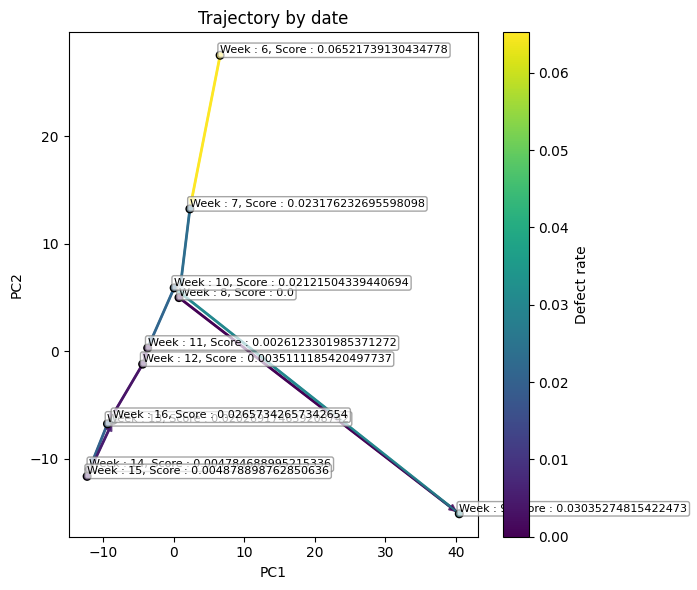

In [24]:


points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(score.min(), score.max())

lc = LineCollection(
    segments,
    cmap='viridis',
    norm=norm,
    linewidth=2
)
lc.set_array(score[:-1])

fig, ax = plt.subplots(figsize=(7,6))
ax.add_collection(lc)

# Scatter
sc = ax.scatter(
    x, y,
    c=score,
    cmap='viridis',
    norm=norm,
    s=30,
    edgecolor='k',
    zorder=3
)

# #1. 화살표 추가
for i in range(len(x) - 1) : 
    arrow = FancyArrowPatch(
        (x[i], y[i]),
        (x[i+1], y[i+1]),
        arrowstyle="-|>",
        mutation_scale=10,
        color=plt.cm.viridis(norm(score[i])),
        linewidth=1.5,
        alpha=0.8,
        zorder=2,
    )
    ax.add_patch(arrow)

# 2. 레이블 추가
for real_idx, idx in enumerate(data_sv_pca.index.tolist()) : 
    ax.text(
        x[real_idx],
        y[real_idx],
        f"Week : {week[real_idx]}, Score : {score[real_idx]}",
        fontsize=8,
        ha='left',
        va='bottom',
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc='white',
            alpha=0.7,
            ec='gray'
        )
    )

ax.autoscale()

cbar = fig.colorbar(sc, ax=ax)
# locator = mdates.AutoDateLocator()
# formatter = mdates.ConciseDateFormatter(locator)
# cbar.ax.yaxis.set_major_locator(locator)
# cbar.ax.yaxis.set_major_formatter(formatter)
cbar.set_label('Defect rate')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectory by date")

plt.tight_layout()
plt.show()

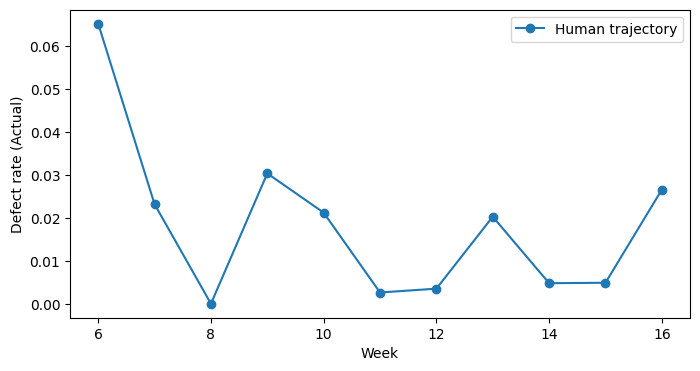

In [25]:
plt.figure(figsize=(8, 4))

plt.plot(
    data_sv_mean_by_week.index.tolist(),
    (1-data_sv_mean_by_week['Y_NFF_A']).tolist(),
    marker='o',
    label='Human trajectory'
)
plt.xlabel('Week')
plt.ylabel('Defect rate (Actual)')
plt.legend()

plt.show()

In [26]:
data_sv_pca

,PC1,PC2,Y_NFF_A
week,,,
6,6.589147,27.547535,0.934783
7,2.301782,13.255460,0.976824
8,0.757794,5.003513,1.000000
9,40.502193,-15.108627,0.969647
10,0.072633,5.907004,0.978785
11,-3.680634,0.313389,0.997388
12,-4.394294,-1.187104,0.996489
13,-9.385357,-6.739692,0.979731
14,-11.956199,-10.963002,0.995215


# 백테스트

In [27]:
data_sv_mean_by_week

,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_[B_EL Filling Chamber] 평균값 보정 보정범위(상한),X_SV_Assemble_Assembly_Paramter Target Value_[1A] Chamber [공정#2] 압력 설정값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 11 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 3 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 10 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 1 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 5 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,Y_NFF_A
week,,,,,,,,,,,,,,,,,,,,,
6,474.198147,481.926068,111.415333,5.766639,133.250590,142.050463,1296.461004,255.310783,30.685131,78.862286,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.934783
7,474.902227,485.044036,329.344417,7.485885,137.495781,129.584097,1304.705519,255.683532,30.747255,78.629003,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.976824
8,475.445192,489.703330,570.124000,9.920800,140.769540,119.970424,1317.039415,255.970984,30.795164,78.329349,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,1.000000
9,474.557306,495.013582,568.622654,9.933170,135.483267,135.480875,1331.155838,255.500821,30.717096,77.895296,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.969647
10,474.034130,497.329834,530.114408,9.473250,133.496263,141.087458,1337.310233,255.222020,30.675711,77.708580,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.978785
11,474.714096,497.149338,539.318046,9.807290,138.560414,126.027460,1336.835146,255.580493,30.739655,77.719184,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.997388
12,474.613030,497.400101,572.458451,9.980552,135.752095,134.704579,1337.500000,255.530428,30.721738,77.700226,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.996489
13,474.792994,497.370301,570.081466,9.957230,136.837169,131.518167,1337.420834,255.625703,30.737617,77.702617,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.979731
14,475.450618,497.400000,574.669255,9.994248,140.802258,119.874346,1337.500000,255.973857,30.795643,77.700000,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.995215


In [28]:
data['week']

0           9
1          12
2           7
3          13
4           7
         ... 
14760    <NA>
14761       6
14762      13
14763       7
14764       9
Name: week, Length: 59060, dtype: UInt32

In [29]:
from model import CascadeModel

In [30]:
model_name = 'N32S'
n_trials = 300
lb_margin = 0.05
ub_margin = 0.05
threshold_constraint = 4

In [31]:
import gc

In [32]:
# for week in range(15, 17) : 
#     gc.collect()
#     # 1. 데이터 Split
#     x = data.loc[lambda x : x['week']<=week]
#     y = data.loc[lambda x : x['week']<=week]
#     x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
#     del x
#     del y
#     gc.collect()

#     # 2-1. 모델 불러오기
#     filename_model = f"model_{model_name}_week_{week}.dill"
#     if os.path.exists(filename_model) :
#         with open(filename_model, 'rb') as f : 
#             model = dill.load(f)
    
#     else : # 2-2. 없으면 모델 학습
#         input_profile = 'Big_Y-Activation'

#         INPUT_PROFILE = {
#             'Big_Y-Activation' : [
#                 'SV-Mixing',
#                 'SV-Roll Pressing',
#                 'SV-Slitting',
#                 'SV-Winding',
#                 'SV-Assembly',
#                 #'SV-Activation'
#             ]
#         }
#         model = CascadeModel(input_profile=INPUT_PROFILE, df_cols=df_cols)

#         model.fit(x_train, y_train)
        
#         with open(f'model_week_{week}.dill', 'wb') as f : 
#             dill.dump(model, f)
    
#     # 2-3. 예측값 생성
#     pred = model.predict(x_test)

#     # 3. 초기값 설정
#     x0 = (
#         x_train
#         # .reset_index(drop=False)
#         # .loc[lambda x : x['week']<=week]
#         .iloc[-1]
#     )

#     # 4. 상/하한 설정
#     bounds = {
#         col : (data_sv_mean_by_week[col].min() - abs(data_sv_mean_by_week[col].min() )*lb_margin, 
#         data_sv_mean_by_week[col].max() + abs(data_sv_mean_by_week[col].max())*ub_margin)
#         for col in data_sv_count_by_week.columns
#     }
#     print('bounds')
#     print(bounds)
    
#     # 5. Constraint로 넣을 컬럼 설정
#     cols_to_fix = data_sv_mean_by_week.nunique()[data_sv_mean_by_week.nunique()<=threshold_constraint].index.tolist()

#     # 6. 목적함수 정의
#     opt_cols = cols_sv

#     def clean_col_name(col):
#         col=str(col)
#         col=re.sub(R"_+", "_",col)
#         col=re.sub(r"[^가-힣a-zA-Z0-9_]", "_", col)
#         return col

#     def objective(trial):
#         712gc.collect()
#         print(f"Running trial {trial.number} in {threading.current_thread()}")
#         # 6-1. 초기값 설정
#         x_new = x0.copy()

#         # 6-2. Constraint 제외하고 변경할 값 제안
#         opt_cols_modified = list(set(opt_cols) - set(cols_to_fix))
#         print('opt_cols_modified')
#         print(opt_cols_modified)
#         for col in opt_cols_modified : 
#             low, high = bounds[col]
#             x_new[col] = trial.suggest_float(col, low, high)

#         X = pd.DataFrame([x_new])
        
#         #X.columns = [clean_col_name(c) for c in X.columns]

#         p_bad = model.predict(X)
#         return p_bad

#     # 7. 최적화
#     study = optuna.create_study(direction='maximize')
#     study.optimize(objective, n_trials=n_trials, show_progress_bar=False, n_jobs=16)

#     # 8. 결과 저장
#     pd.DataFrame([study.best_params]).to_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_{week}.csv")


In [34]:
data_sv_result = pd.concat([
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_6.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_7.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_8.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_9.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_10.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_11.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_12.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_13.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_14.csv").drop('Unnamed: 0', axis=1),
    pd.read_csv(f"result_{model_name}_maximize_n_trials_{n_trials}_week_15.csv").drop('Unnamed: 0', axis=1),
], axis=0)
data_sv_result.index = [
    106,
    107,
    108,
    109,
    110,
    111,
    112,
    113,
    114,
    115
]
data_sv_result 

,X_SV_Assemble_Assembly_Parameter Value_용접 에너지 #7,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Assemble_Winding_Parameter Value_JR 음극 프레스 포밍 프레스 원점 거리,X_SV_Assemble_Winding_Parameter Value_음극 흄 석션 하한 유량,X_SV_Electrode_Mixing_Cathode_Parameter Spec LSL_1 Step Input Material 2 Set Weight,X_SV_Assemble_Assembly_Parameter Value_하부 1번 Head 사용 지점,X_SV_Assemble_Assembly_Parameter Value_하부 10번 Head 사용 지점,X_Anode_SV_Electrode_Roll Pressing_Parameter Value_2nd Lower Bender Pressure (OS),X_SV_Assemble_Winding_Paramter Target Value_Hi-pot CHG Input,X_SV_Assemble_Winding_Parameter Value_사행 Vision,...,X_SV_Electrode_Slitting_Anode_Parameter Value_Lower Rewinder Tension,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Assemble_Winding_Parameter Value_실테이프 잔량 부착 속도,X_SV_Electrode_Mixing_Cathode_Parameter Spec USL_1 Step Input Material 3 Set Weight,X_Cathode_SV_Electrode_Roll Pressing_Parameter Value_2nd Stretching Tension,X_SV_Electrode_Mixing_Anode_Parameter Spec USL_2 Step Input Material 1 Set Weight,X_SV_Assemble_Winding_Parameter Value_음극 엔코더 스케일,X_SV_Assemble_Winding_Parameter Value_실테이프 컷팅 회전 속도,X_SV_Electrode_Mixing_Cathode_Parameter Spec LSL_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight
106,8.712226,518.175668,6.187181,2.566000,332.392505,-2.058582,-2.017867,60.930826,0.138311,0.686331,...,45.378238,30.087925,1113.291064,1330.428957,377.784950,262.971562,0.996585,1128.427262,77.826767,486.577398
107,3.169350,481.368444,5.864257,2.422836,355.278884,-2.043548,-1.866368,65.611376,0.039517,0.540157,...,47.946228,31.144019,1097.018292,1311.390184,374.714906,255.968853,1.049849,1151.150301,80.392783,455.958082
108,3.868097,464.143603,6.095623,2.514342,372.914865,-1.964569,-2.019596,68.255151,0.055128,0.419846,...,45.016100,30.662042,1041.869313,1373.976165,381.288394,244.644616,0.994817,968.181273,79.136870,488.645842
109,4.520607,496.434964,5.857028,2.574980,340.219469,-2.129513,-1.885937,65.025678,0.133053,0.887519,...,49.100554,30.636922,1040.804270,1252.933555,332.997370,267.704139,1.012676,1111.544823,77.528719,490.581738
110,4.971193,481.495456,6.129180,2.452770,338.688228,-1.959668,-2.046126,71.713386,0.075396,0.321207,...,51.104951,29.201664,1063.441374,1270.369489,368.168291,246.291369,0.993209,1057.381504,80.524471,471.919033
111,5.769248,464.909949,6.093578,2.332139,359.870409,-1.841677,-2.051640,72.265209,0.056632,0.658584,...,43.383798,32.231240,1014.571320,1391.338440,399.771784,261.951044,0.973307,1022.700259,74.867859,456.680120
112,14.085554,499.272710,5.893810,2.378388,370.416650,-2.130828,-2.128477,72.286271,0.079813,0.654653,...,44.468624,32.331154,1121.585301,1346.632553,336.642146,260.286242,1.027115,1029.297140,79.161384,498.573051
113,7.467853,489.847180,5.965992,2.512607,369.941000,-2.146312,-2.057257,70.789473,0.074451,0.638433,...,47.791721,29.782335,1038.906118,1346.086351,381.466689,265.105088,0.951574,981.999886,79.884018,482.979783
114,6.990110,503.599202,6.358947,2.470807,347.616459,-2.071039,-2.011942,71.414658,0.037934,0.915269,...,50.226619,30.908426,1135.085750,1323.700924,408.518425,262.750334,0.971657,1003.607085,73.466653,483.611296
115,9.077655,471.736963,5.823747,2.324079,352.145542,-2.048852,-2.141549,73.083882,0.048865,0.185032,...,50.686049,30.644448,1040.460072,1263.298865,410.217698,268.395809,1.010825,999.785516,74.022287,469.184028


In [35]:
data_sv_mean_by_week_with_param = pd.concat([data_sv_mean_by_week, data_sv_result], axis=0)
data_sv_mean_by_week_with_param = data_sv_mean_by_week_with_param
for col in data_sv_mean_by_week_with_param.drop('Y_NFF_A', axis=1).columns : 
    data_sv_mean_by_week_with_param[col] = data_sv_mean_by_week_with_param[col].ffill()
data_sv_mean_by_week_with_param

,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 6 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_7-1 Step Vacuum Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 3 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_3 Step Input Material 2 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 2 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_[B_EL Filling Chamber] 평균값 보정 보정범위(상한),X_SV_Assemble_Assembly_Paramter Target Value_[1A] Chamber [공정#2] 압력 설정값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 11 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 3 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 10 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 1 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 5 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,Y_NFF_A
6,474.198147,481.926068,111.415333,5.766639,133.250590,142.050463,1296.461004,255.310783,30.685131,78.862286,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.934783
7,474.902227,485.044036,329.344417,7.485885,137.495781,129.584097,1304.705519,255.683532,30.747255,78.629003,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.976824
8,475.445192,489.703330,570.124000,9.920800,140.769540,119.970424,1317.039415,255.970984,30.795164,78.329349,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,1.000000
9,474.557306,495.013582,568.622654,9.933170,135.483267,135.480875,1331.155838,255.500821,30.717096,77.895296,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.969647
10,474.034130,497.329834,530.114408,9.473250,133.496263,141.087458,1337.310233,255.222020,30.675711,77.708580,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.978785
11,474.714096,497.149338,539.318046,9.807290,138.560414,126.027460,1336.835146,255.580493,30.739655,77.719184,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.997388
12,474.613030,497.400101,572.458451,9.980552,135.752095,134.704579,1337.500000,255.530428,30.721738,77.700226,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.996489
13,474.792994,497.370301,570.081466,9.957230,136.837169,131.518167,1337.420834,255.625703,30.737617,77.702617,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.979731
14,475.450618,497.400000,574.669255,9.994248,140.802258,119.874346,1337.500000,255.973857,30.795643,77.700000,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.995215
15,475.404893,497.397182,572.983164,9.964925,140.526561,120.683953,1337.492304,255.949649,30.791608,77.700410,...,0.7,0.84,-0.23,-0.18,-0.21,-0.2,-0.19,-0.23,-0.2,0.995121


In [36]:
data_sv_mean_by_week = data_sv_mean_by_week_with_param

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_sv_mean_by_week.drop('Y_NFF_A', axis=1))


if not os.path.exists('pca.dill') : 
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    with open('pca.dill', 'wb') as f : 
        dill.dump(pca, f)
else : 
    with open('pca.dill', 'rb') as f : 
        pca = dill.load(f)
    X_pca = pca.transform((X_scaled))


In [38]:
data_sv_pca = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=getattr(data_sv_mean_by_week, "index", None)
)
data_sv_pca['Y_NFF_A'] = data_sv_mean_by_week['Y_NFF_A']

In [39]:
x = data_sv_pca['PC1'].values
y = data_sv_pca['PC2'].values
score = (1-data_sv_pca['Y_NFF_A'].values)
week = data_sv_pca.index.tolist()

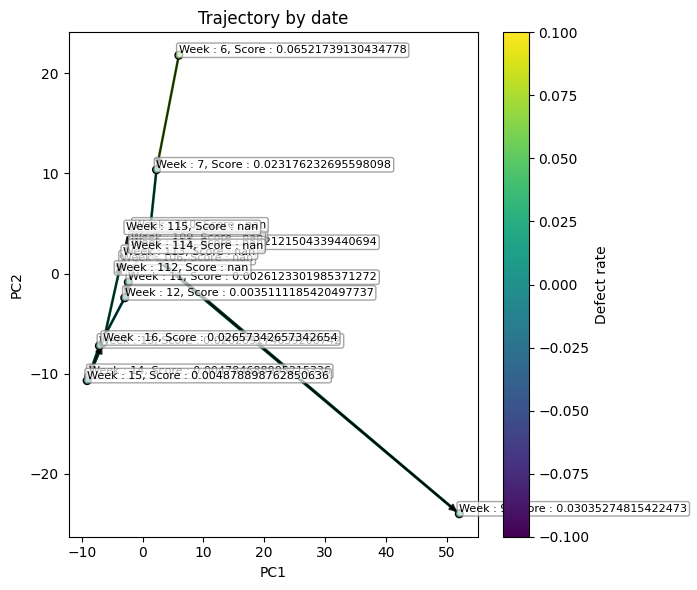

In [40]:


points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(score.min(), score.max())

lc = LineCollection(
    segments,
    cmap='viridis',
    norm=norm,
    linewidth=2
)
lc.set_array(score[:-1])

fig, ax = plt.subplots(figsize=(7,6))
ax.add_collection(lc)

# Scatter
sc = ax.scatter(
    x, y,
    c=score,
    cmap='viridis',
    norm=norm,
    s=30,
    edgecolor='k',
    zorder=3
)

# #1. 화살표 추가
for i in range(len(x) - 1) : 
    arrow = FancyArrowPatch(
        (x[i], y[i]),
        (x[i+1], y[i+1]),
        arrowstyle="-|>",
        mutation_scale=10,
        color=plt.cm.viridis(norm(score[i])),
        linewidth=1.5,
        alpha=0.8,
        zorder=2,
    )
    ax.add_patch(arrow)

# 2. 레이블 추가
for real_idx, idx in enumerate(data_sv_pca.index.tolist()) : 
    ax.text(
        x[real_idx],
        y[real_idx],
        f"Week : {week[real_idx]}, Score : {score[real_idx]}",
        fontsize=8,
        ha='left',
        va='bottom',
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc='white',
            alpha=0.7,
            ec='gray'
        )
    )

ax.autoscale()

cbar = fig.colorbar(sc, ax=ax)
# locator = mdates.AutoDateLocator()
# formatter = mdates.ConciseDateFormatter(locator)
# cbar.ax.yaxis.set_major_locator(locator)
# cbar.ax.yaxis.set_major_formatter(formatter)
cbar.set_label('Defect rate')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectory by date")

plt.tight_layout()
plt.show()

In [41]:
data_sv_pca

,PC1,PC2,Y_NFF_A
6,5.964122,21.803153,0.934783
7,2.292688,10.374712,0.976824
8,0.886538,2.345210,1.000000
9,52.090853,-23.973530,0.969647
10,-0.051053,2.633262,0.978785
11,-2.340340,-0.850995,0.997388
12,-2.929549,-2.413104,0.996489
13,-7.101054,-7.207127,0.979731
14,-8.848684,-10.244059,0.995215
15,-9.113638,-10.677046,0.995121


: 